# Notebook 10 – Support Vector Machine (SVM)
Using `data.csv` (retail orders)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
%matplotlib inline

**Our goal:** Predict if an order is **"High Value"** or **"Low Value"** using just `Quantity` and `UnitPrice`.

In [2]:
df = pd.read_csv('data.csv', encoding='latin1')
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['HighValue'] = (df['TotalPrice'] > df['TotalPrice'].mean()).astype(int)
data = df.sample(n=1000, random_state=1)
X = data[['Quantity', 'UnitPrice']].values
y = data['HighValue'].values
data[['Quantity', 'UnitPrice', 'HighValue']].head()

,Quantity,UnitPrice,HighValue
67531,6,7.95,1
538383,2,1.25,0
2067,3,1.25,0
21121,1,8.47,0
39577,2,3.75,0


## 1. Support Vector Machine (SVM)
**What:** An algorithm that draws a boundary to separate two groups of data.
**Example:** Separate "High Value" orders from "Low Value" orders using `Quantity` and `UnitPrice`.
**Why:** Lets us automatically flag order types without manual checking.


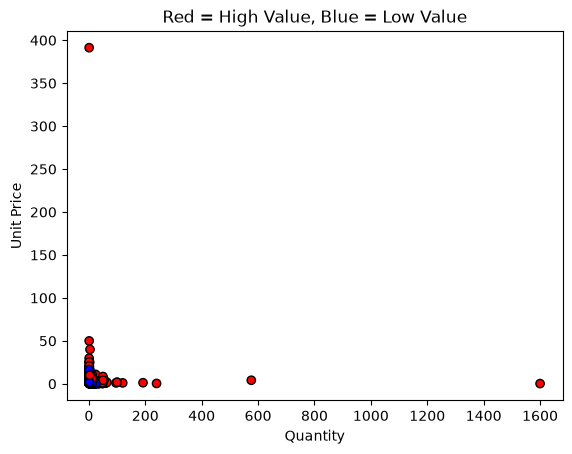

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.title('Red = High Value, Blue = Low Value')
plt.show()

## 2. Hyperplane
**What:** The boundary line SVM draws between the two groups.
    
**Example:** A line separating High Value from Low Value orders.

**Why:** Any new order is classified by checking which side of the line it falls on.


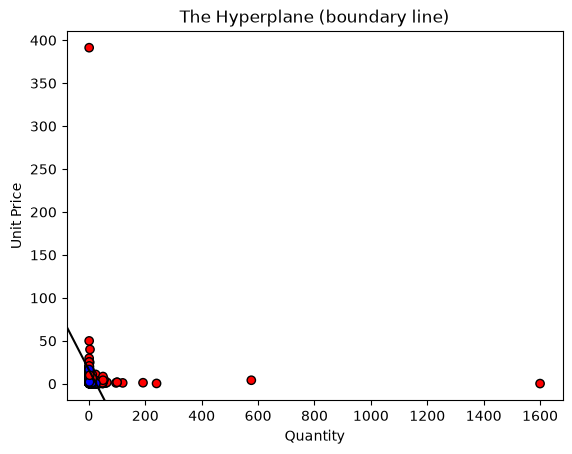

In [4]:
model = SVC(kernel='linear')
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
ax = plt.gca()
xx = np.linspace(*ax.get_xlim(), 30)
yy = np.linspace(*ax.get_ylim(), 30)
YY, XX = np.meshgrid(yy, xx)
Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
ax.contour(XX, YY, Z, levels=[0], colors='k')
plt.xlabel('Quantity'); plt.ylabel('Unit Price')
plt.title('The Hyperplane (boundary line)')
plt.show()

## 3. Margin
**What:** The gap between the boundary and the closest points on each side. SVM makes this gap as wide as possible.

**Example:** The dashed lines below show the margin around our boundary.
    
**Why:** A wider margin means the model is safer and more confident on new orders.

**Intuition behind maximizing the margin:**
Out of all the possible lines that could separate the two classes, SVM doesn't just pick any line that works — it picks the one **farthest from both groups**. Think of it like parking a car exactly in the middle of two other cars instead of squeezing right next to one. A boundary drawn too close to some points is risky: a slightly different new point could easily land on the wrong side. A wide margin means only the "hardest," most borderline points are close to the line, so the model stays confident and stable even when new data varies slightly from the training data.


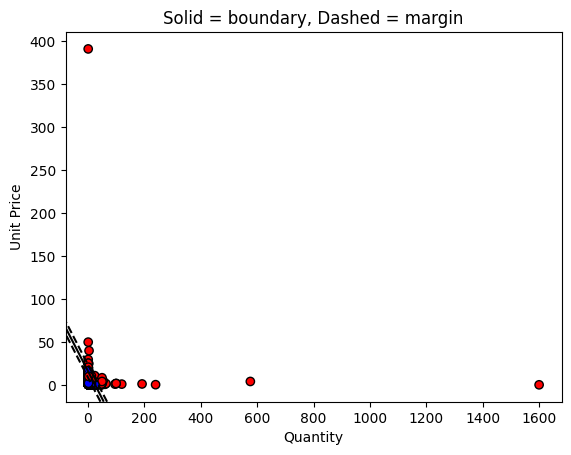

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
ax = plt.gca()
Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
plt.xlabel('Quantity'); plt.ylabel('Unit Price')
plt.title('Solid = boundary, Dashed = margin')
plt.show()


## 4. Support Vectors
**What:** The closest points to the boundary — the only ones that decide where it sits.

**Example:** The borderline orders (not clearly cheap or expensive) that shape our line.
    
**Why:** Shows SVM only needs the "hard" points, not every single order.


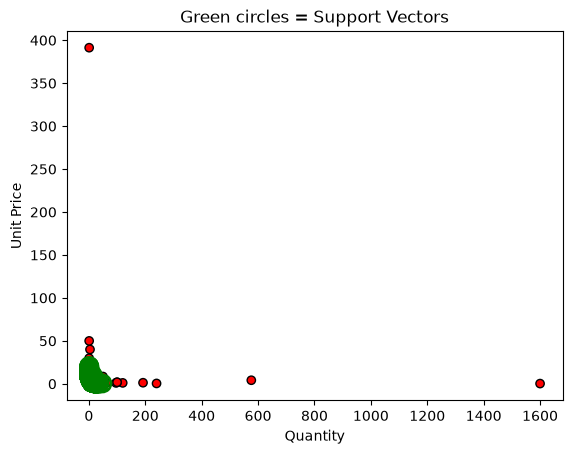

Number of support vectors: 283


In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='green', linewidths=2)
plt.xlabel('Quantity'); plt.ylabel('Unit Price')
plt.title('Green circles = Support Vectors')
plt.show()
print("Number of support vectors:", len(model.support_vectors_))

## 5. Linear SVM
**What:** Uses a plain straight line to separate the groups.
    
**Example:** The line we already drew above.
    
**Why:** It's the simplest, fastest option — worth trying first.


In [6]:
print("Linear SVM accuracy:", model.score(X, y))

Linear SVM accuracy: 0.864


## 6. Non-Linear SVM
**What:** Since `TotalPrice = Quantity x UnitPrice`, the true boundary is a curve, not a straight line.
    
**Example:** A cheap item bought in bulk can equal an expensive item bought once — a straight line can't capture that.

**Why:** Real relationships are often curved, not simple straight lines.


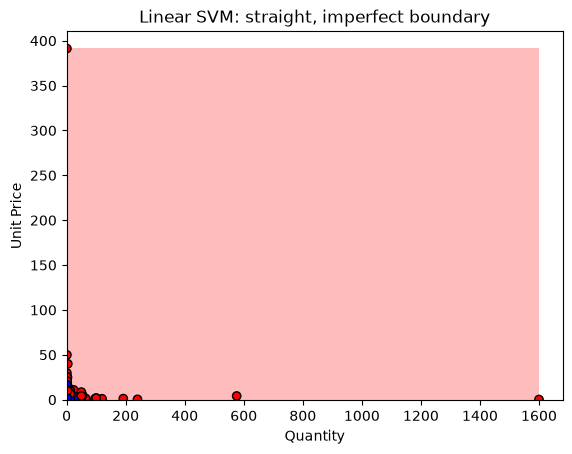

In [7]:
def plot_boundary(model, X, y, title):
    h = (X[:,0].max()-X[:,0].min())/200
    xx, yy = np.meshgrid(np.arange(X[:,0].min()-1, X[:,0].max()+1, h),
                          np.arange(X[:,1].min()-1, X[:,1].max()+1, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    plt.xlabel('Quantity'); plt.ylabel('Unit Price'); plt.title(title)
    plt.show()
plot_boundary(model, X, y, "Linear SVM: straight, imperfect boundary")

## 7. Kernel
**What:** A trick that lets SVM draw curved boundaries instead of just straight lines.
    
**Example:** Using a kernel helps SVM "see" the Quantity x UnitPrice pattern.
    
**Why:** Without it, SVM is stuck with straight lines only.


In [8]:
kernel_model = SVC(kernel='rbf')
kernel_model.fit(X, y)
print("RBF kernel accuracy:", kernel_model.score(X, y))

RBF kernel accuracy: 0.863


## 8. RBF Kernel
**What:** The most popular kernel — uses "closeness" between points to draw flexible, curved boundaries.

**Example:** See the curved boundary below, following our data's pattern.

**Why:** Works well by default on most real, messy data.


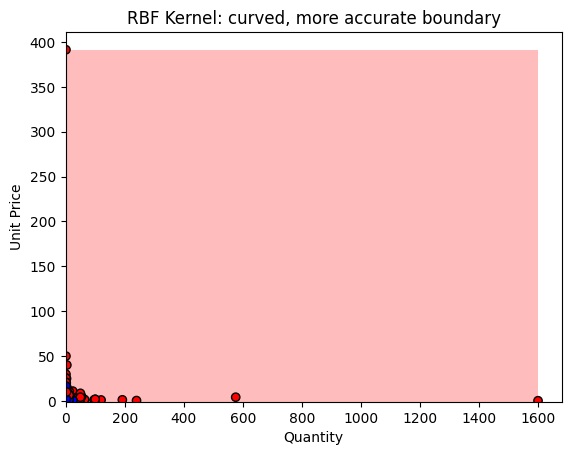

In [10]:
plot_boundary(kernel_model, X, y, "RBF Kernel: curved, more accurate boundary")

## 9. C Parameter
**What:** Balances "wide margin" vs "get every point right." Low C = relaxed. High C = strict.
                                                                                     
**Example:** A high C forces the model to bend its boundary around odd/noisy orders.
    
**Why:** Helps the model ignore a few weird orders instead of overreacting.


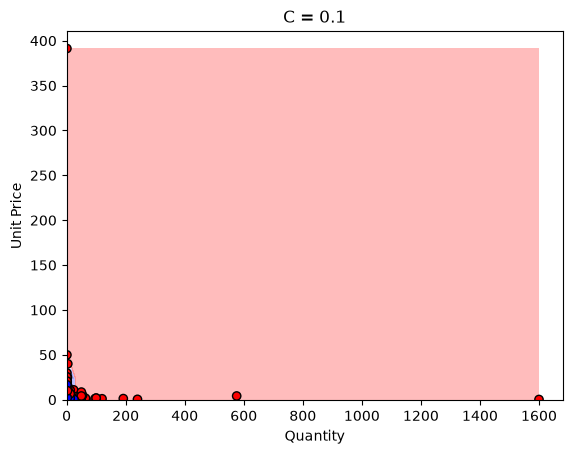

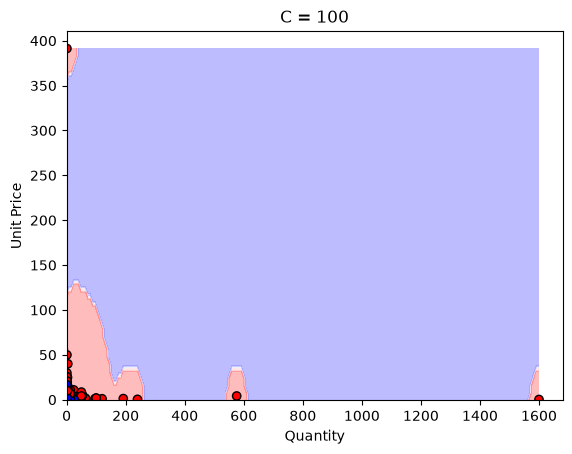

In [9]:
for c in [0.1, 100]:
    m = SVC(kernel='rbf', C=c).fit(X, y)
    plot_boundary(m, X, y, f"C = {c}")

## 10. Gamma
**What:** Controls how far one point's influence spreads. Low = smooth. High = tightly wrapped (overfitting risk).

**Example:** High gamma might curve tightly around just one unusual order.

**Why:** Keeps the boundary general, not just memorized for training data.


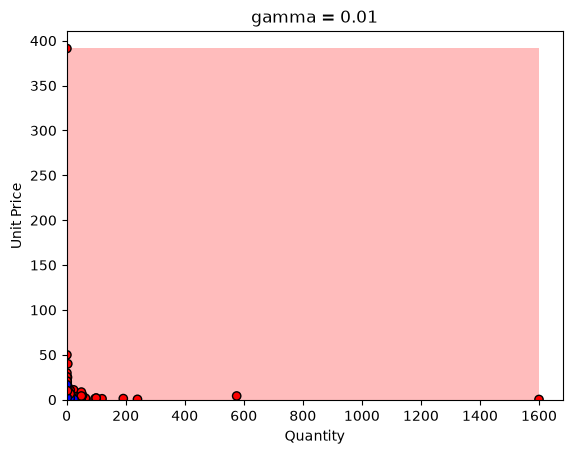

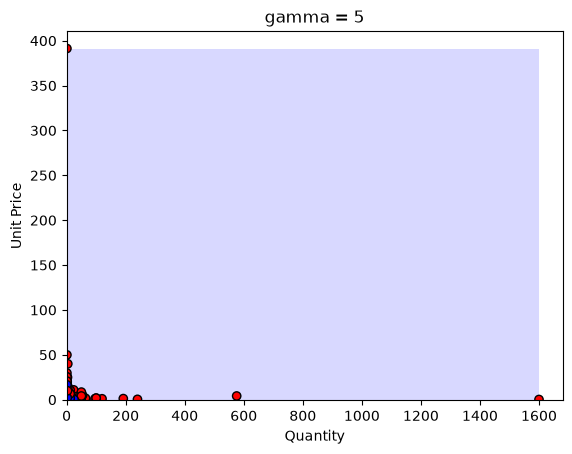

In [10]:
for g in [0.01, 5]:
    m = SVC(kernel='rbf', gamma=g).fit(X, y)
    plot_boundary(m, X, y, f"gamma = {g}")

## 11. Feature Scaling
**What:** Puts all features on the same scale, since SVM relies on distances.
    
**Example:** `Quantity` can be much bigger than `UnitPrice` — without scaling, it unfairly dominates.

**Why:** Ensures both features get a fair say in the boundary.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
no_scale = SVC(kernel='rbf').fit(X_train, y_train)
acc_no_scale = accuracy_score(y_test, no_scale.predict(X_test))
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
scaled = SVC(kernel='rbf').fit(X_train_s, y_train)
acc_scaled = accuracy_score(y_test, scaled.predict(X_test_s))
print("Accuracy WITHOUT scaling:", round(acc_no_scale, 3))
print("Accuracy WITH scaling:   ", round(acc_scaled, 3))

Accuracy WITHOUT scaling: 0.843
Accuracy WITH scaling:    0.843
